# OpenCV 기초 — 이미지 입출력 · 색공간 실습

> **강의자료**: `강의자료/04.01.OpenCV-Basic.md`

| Part | 주제 |
|------|------|
| Part 1 | 컴퓨터 비전과 OpenCV |
| Part 2 | 설치 및 이미지 기본 구조 |
| Part 3 | 이미지 입출력 |
| Part 4 | 색공간 변환 |
| Part 5 | 퀴즈 & 복습 |

이 실습 파일에서는 OpenCV를 이용해 이미지를 읽고, 화면에 출력하고, 저장하는
기본 입출력 흐름과 색공간(BGR, Grayscale, HSV) 변환 방법을 배웁니다.
로봇 비전의 기초가 되는 핵심 개념들을 직접 코드로 확인해 봅니다.

---
## Part 1: 컴퓨터 비전과 OpenCV

로봇에게 "시각"을 부여하는 기술, 컴퓨터 비전과 OpenCV를 소개합니다.

### 1.1 컴퓨터 비전이 로봇 개발에 왜 필요한가?

- **카메라 없는 로봇 (Blind Robot)**
    - 미리 입력된 궤적만 반복하는 "맹목적인 반복성"에 의존
    - 환경 변화나 장애물에 적응하지 못해 사고 발생 위험

- **카메라 있는 로봇 (Perception-driven Robot)**
    - **물체 감지 및 좌표 판별**: 임의 위치 부품을 찾아 집어 올림
    - **적응형 내비게이션**: 실시간 장애물 감지 및 경로 수정
    - **인간-로봇 상호작용(HRI)**: 제스처·얼굴 인식으로 협업

### 1.2 OpenCV — 로봇 비전의 표준

- **OpenCV (Open Source Computer Vision Library)**
    - 컴퓨터 비전 및 머신러닝을 위한 강력한 오픈소스 라이브러리
    - 1999년 Intel에서 개발 시작

- **로봇 비전의 표준이 된 이유**
    - **광범위한 기능**: 기초 필터링부터 객체 탐지, 얼굴 인식, 3D 재구성까지
    - **다중 언어 및 플랫폼 지원**: C++, Python, Java / 모든 주요 OS
    - **실시간 처리 능력**: 임베디드 시스템에서도 동작 가능한 경량 설계
    - **강력한 커뮤니티**: 최신 논문 알고리즘이 빠르게 업데이트

---
## Part 2: 설치 및 이미지 기본 구조

OpenCV 설치 방법과 이미지가 컴퓨터에서 표현되는 방식을 알아봅니다.

### 2.1 설치 가이드

| 패키지 | 내용 | 권장 상황 |
|--------|------|-----------|
| `opencv-python` | 메인 모듈만 포함 | 입문 단계 |
| `opencv-contrib-python` | 메인 + 추가 모듈 (SIFT, SURF 등) | 고급 특징점 매칭 |

⚠ 두 패키지를 동시에 설치하면 **충돌 발생** → 하나만 설치

```
pip install opencv-python==4.10.0.84
```

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 2.2 이미지가 컴퓨터에서 표현되는 방식

- **픽셀 (Pixel)**: 이미지의 최소 단위인 점. 각 점에 색상 정보가 숫자로 담김
- **채널 (Channel)**: 색상을 표현하는 성분
    - **그레이스케일**: 밝기 1채널 (0 ~ 255)
    - **컬러**: 보통 3채널 (BGR)
- **NumPy 배열**: OpenCV 이미지는 `(높이, 너비, 채널 수)` 형태의 NumPy 배열

컬러 이미지 shape: (100, 100, 3)
데이터 타입: uint8


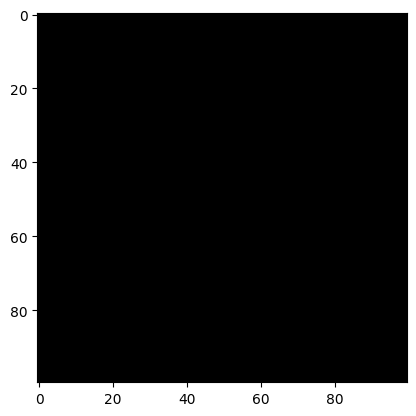

In [3]:
# NumPy로 직접 이미지 배열 구조 확인하기
# 실제 이미지 없이도 배열 구조를 이해할 수 있음

# 100x100 크기의 컬러 이미지(3채널) 생성 (모든 픽셀 = 0, 검정)
blank_color = np.zeros((100, 100, 3), dtype=np.uint8)
print(f"컬러 이미지 shape: {blank_color.shape}")   # (100, 100, 3)
print(f"데이터 타입: {blank_color.dtype}")          # uint8 (0~255)
plt.imshow(blank_color)

컬러 이미지 shape: (100, 100, 3)
데이터 타입: uint8


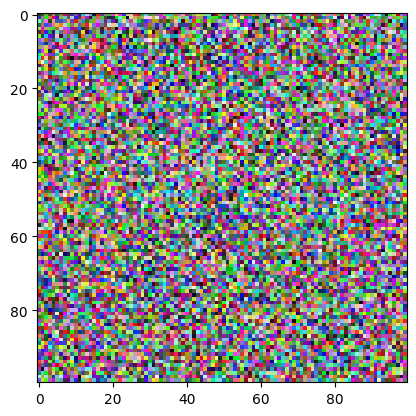

In [4]:
# 100x100 크기의 컬러 이미지(3채널) 생성 (모든 픽셀 랜덤)
random_color = (np.random.rand(100, 100, 3) * 255).astype(np.uint8)
print(f"컬러 이미지 shape: {random_color.shape}")   # (100, 100, 3)
print(f"데이터 타입: {random_color.dtype}")          # uint8 (0~255)
plt.imshow(random_color)

그레이스케일 이미지 shape: (100, 100)


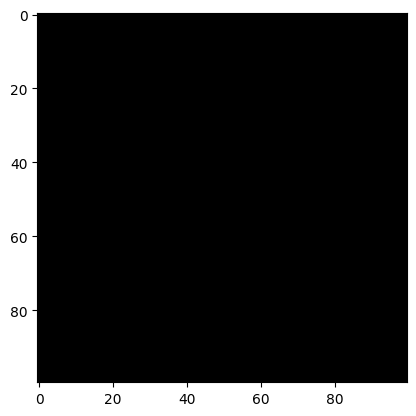

In [5]:
# 100x100 크기의 그레이스케일 이미지(1채널) 생성
blank_gray = np.zeros((100, 100), dtype=np.uint8)
print(f"그레이스케일 이미지 shape: {blank_gray.shape}")  # (100, 100) — 2차원!
plt.imshow(blank_gray, cmap="gray")

그레이스케일 이미지 shape: (100, 100)


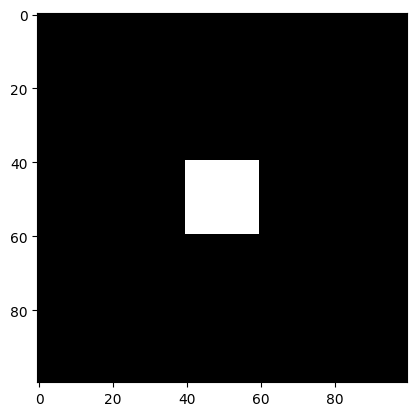

In [6]:
# 100x100 크기의 그레이스케일 이미지(1채널) 생성
blank_gray = np.zeros((100, 100), dtype=np.uint8)
blank_gray[40:60, 40:60] = 255  # 일부분만 흰색으로 변경
print(f"그레이스케일 이미지 shape: {blank_gray.shape}")  # (100, 100) — 2차원!
plt.imshow(blank_gray, cmap="gray")

In [7]:
# NumPy로 단색 이미지 만들기
red_pixel_bgr = np.array([0, 0, 255], dtype=np.uint8)   # BGR 순서: B=0, G=0, R=255
print(f"빨간색 픽셀 (BGR): {red_pixel_bgr}")

빨간색 픽셀 (BGR): [  0   0 255]


빨간색 이미지 shape: (100, 100, 3)


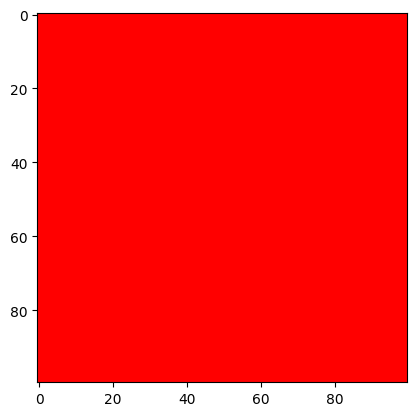

In [ ]:
# 100x100 빨간색 이미지 생성
red_image = np.full((100, 100, 3), [0, 0, 255], dtype=np.uint8)
print(f"빨간색 이미지 shape: {red_image.shape}")
plt.imshow(cv2.cvtColor(red_image, cv2.COLOR_BGR2RGB))
#plt.imshow(red_image)
#RGB, BGR 순서 주의! OpenCV는 BGR, Matplotlib는 RGB

### 2.3 BGR 컨벤션 — OpenCV의 색상 채널 순서

| 라이브러리 | 채널 순서 | 픽셀 배열 첫 번째 값 |
|:---:|:---:|:---:|
| OpenCV | **B - G - R** | 파랑(Blue) |
| Matplotlib, PIL 등 | R - G - B | 빨강(Red) |

⚠ OpenCV 이미지를 Matplotlib으로 바로 출력하면 색상이 어색하게 보임!
해결: `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)` 로 변환

In [11]:
# BGR 채널 순서 직접 확인
white_pixel = np.array([[[255, 255, 255]]], dtype=np.uint8)   # 흰색 픽셀
pure_blue   = np.array([[[255,   0,   0]]], dtype=np.uint8)   # BGR에서 파랑
pure_green  = np.array([[[  0, 255,   0]]], dtype=np.uint8)   # BGR에서 초록
pure_red    = np.array([[[  0,   0, 255]]], dtype=np.uint8)   # BGR에서 빨강

print("BGR 채널 순서 — [B, G, R]")
print(f"순수 파랑 픽셀: {pure_blue[0,0]}  → B={pure_blue[0,0,0]}, G={pure_blue[0,0,1]}, R={pure_blue[0,0,2]}")
print(f"순수 빨강 픽셀: {pure_red[0,0]}   → B={pure_red[0,0,0]}, G={pure_red[0,0,1]}, R={pure_red[0,0,2]}")

BGR 채널 순서 — [B, G, R]
순수 파랑 픽셀: [255   0   0]  → B=255, G=0, R=0
순수 빨강 픽셀: [  0   0 255]   → B=0, G=0, R=255


---
## Part 3: 이미지 입출력

로봇 카메라 이미지를 읽고, 화면에 출력하고, 저장하는 기본 흐름을 배웁니다.

### 3.1 이미지 입출력 핵심 함수 4가지

| 함수 | 역할 |
|------|------|
| `cv2.imread(filepath)` | 이미지 파일 읽기 → NumPy 배열 반환 |
| `cv2.imshow(window_name, image)` | 이미지 화면 출력 |
| `cv2.waitKey(delay_ms)` | 키보드 입력 대기 (`0`=무한 대기) |
| `cv2.imwrite(filepath, image)` | 이미지 파일 저장 |

⚠ `cv2.imread()` 가 파일을 찾지 못하면 **None 반환** (에러가 아님!) → 반드시 검사 필요

In [3]:
# 인터넷에서 이미지 다운로드

import urllib.request

image_url = 'https://www.cats.org.uk/media/1rmh2v5d/230215case104.jpg'
image_path = 'sample.jpg'

urllib.request.urlretrieve(image_url, image_path)
print(f"이미지 다운로드 완료: {image_path}")

이미지 다운로드 완료: sample.jpg


In [13]:
# cv2.imread() 로 이미지 읽기 + None 검사

image_path = 'sample.jpg'

image = cv2.imread(image_path)

print(f"이미지 로드 성공: shape={image.shape}, dtype={image.dtype}")

이미지 로드 성공: shape=(5464, 8192, 3), dtype=uint8


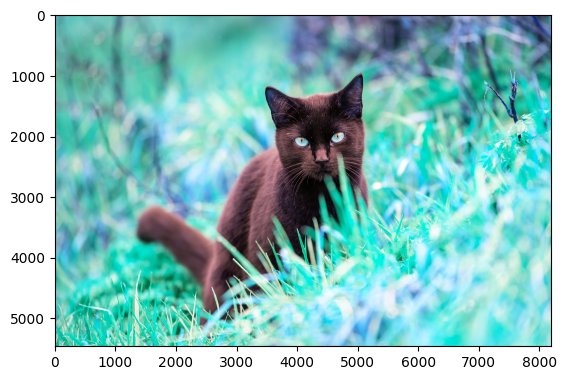

In [15]:
#plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.imshow(image)  # OpenCV는 BGR, Matplotlib는 RGB이므로 색상이 이상하게 보임

In [16]:
# cv2.imwrite() 로 이미지 저장
output_path = 'processed_view.png'
success = cv2.imwrite(output_path, image)
print(f"이미지 저장 {'성공' if success else '실패'}: {output_path}")

이미지 저장 성공: processed_view.png


In [17]:
# cv2.imshow() 로 이미지 화면 출력
# ※ 주피터/VS Code Interactive 환경에서는 창이 순간 열렸다가 닫힐 수 있음
#   실제 로봇 코드나 스크립트로 실행할 때 사용

# cv2.imshow('Robot Eye View', image)
# cv2.waitKey(0)           # 키를 누를 때까지 무한 대기
# cv2.destroyAllWindows()  # 모든 OpenCV 창 닫기

In [20]:
# 입문자가 자주 겪는 문제 ① — imread 결과 None 검사 패턴
def safe_imread(path):
    """이미지를 안전하게 읽는 함수. 파일이 없으면 None 대신 에러 메시지 출력."""
    img = cv2.imread(path)
    if img is None:
        print(f"[ERROR] 이미지를 읽을 수 없습니다: '{path}'")
        print("       → 파일 경로가 올바른지, 확장자가 맞는지 확인하세요.")
    return img

result = safe_imread('sample-01.jpg')
print(f"존재하지 않는 파일 읽기 결과: {result.shape}")

[ERROR] 이미지를 읽을 수 없습니다: 'sample-01.jpg'
       → 파일 경로가 올바른지, 확장자가 맞는지 확인하세요.


[ WARN:0@844.511] global loadsave.cpp:241 findDecoder imread_('sample-01.jpg'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'shape'

---
## Part 4: 색공간 변환

색공간이란 이미지에서 색상을 표현하기 위한 수학적 규칙입니다.
로봇 개발에서 상황에 맞는 색공간을 선택하면 인식 정확도가 크게 향상됩니다.

### 4.1 색공간(Color Space)이란?

| 색공간 | 채널 구성 | 주요 활용 |
|:---:|:---:|:---:|
| BGR | 파랑·초록·빨강 | 기본 이미지 읽기·출력 |
| Grayscale | 밝기(1채널) | 엣지 검출, 연산 속도 향상 |
| HSV | 색상·채도·명도 | 특정 색상 물체 탐지·추적 |
| Lab | 밝기·a·b | 정밀한 색차 계산 |

### 4.2 cv2.cvtColor() — 색공간 변환 함수

```python
cv2.cvtColor(src, code)
```

| 변환 코드 | 변환 방향 | 주요 사용 목적 |
|:---:|:---:|:---|
| `cv2.COLOR_BGR2GRAY` | BGR → Grayscale | 엣지 검출, 연산 속도 향상 |
| `cv2.COLOR_BGR2HSV` | BGR → HSV | 특정 색상 물체 탐지·추적 |
| `cv2.COLOR_BGR2RGB` | BGR → RGB | Matplotlib 출력용 |

<img src="https://upload.wikimedia.org/wikipedia/commons/f/f1/HSV_cone.jpg" width="400">

In [21]:
# 색공간 변환 — BGR → Grayscale / HSV / RGB
# (Part 3에서 생성한 image 변수 사용)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Grayscale 변환
hsv  = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)   # HSV 변환
rgb  = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   # Matplotlib 출력용

print("=== 색공간 변환 후 shape 변화 ===")
print(f"원본 BGR  : {image.shape}") 
print(f"Grayscale : {gray.shape}")
print(f"HSV       : {hsv.shape}")
print(f"RGB       : {rgb.shape}")

=== 색공간 변환 후 shape 변화 ===
원본 BGR  : (5464, 8192, 3)
Grayscale : (5464, 8192)
HSV       : (5464, 8192, 3)
RGB       : (5464, 8192, 3)


In [22]:
# Grayscale 변환 후 채널 수가 1→2차원으로 바뀌는 것에 주의
print(f"BGR 배열 차원: {image.ndim}차원")   # 3차원 (H, W, C)
print(f"Gray 배열 차원: {gray.ndim}차원")   # 2차원 (H, W)

# ⚠ 3채널을 기대하는 함수에 Grayscale 배열을 넣으면 에러 발생
# 항상 shape를 확인하는 습관이 중요!

BGR 배열 차원: 3차원
Gray 배열 차원: 2차원


In [25]:
# Grayscale 이미지의 픽셀 값 확인
# 밝기(Luminance)는 BGR 채널의 가중 평균으로 계산됨
print(f"원본 픽셀 (10,10): BGR = {image[10, 10]}")
print(f"그레이 픽셀 (10,10): 밝기 = {gray[10, 10]}")

원본 픽셀 (10,10): BGR = [ 88 174 186]
그레이 픽셀 (10,10): 밝기 = 168


In [24]:
# HSV 색공간 채널 분리 — Hue, Saturation, Value
h_channel = hsv[:, :, 0]   # Hue(색상): 0~179
s_channel = hsv[:, :, 1]   # Saturation(채도): 0~255
v_channel = hsv[:, :, 2]   # Value(명도): 0~255

print(f"HSV 채널 shape: H={h_channel.shape}, S={s_channel.shape}, V={v_channel.shape}")
print(f"Hue 값 범위: {h_channel.min()} ~ {h_channel.max()}")
print(f"Saturation 값 범위: {s_channel.min()} ~ {s_channel.max()}")

HSV 채널 shape: H=(5464, 8192), S=(5464, 8192), V=(5464, 8192)
Hue 값 범위: 0 ~ 179
Saturation 값 범위: 0 ~ 255


### 4.3 HSV를 이용한 특정 색상 물체 탐지

- **로봇 개발에서 HSV가 선호되는 이유**
    - 조명이 변해도 **Hue(색상)** 값은 비교적 안정적으로 유지
    - BGR은 조명 변화에 따라 수치가 크게 달라져 물체 추적이 어려움

- **빨간색의 특수성**
    - 빨간색은 Hue 값이 **0 근처와 180 근처 두 군데**에 존재
    - 두 범위 모두 마스킹 후 합쳐야 정확한 탐지 가능

테스트 이미지 shape: (300, 400, 3)


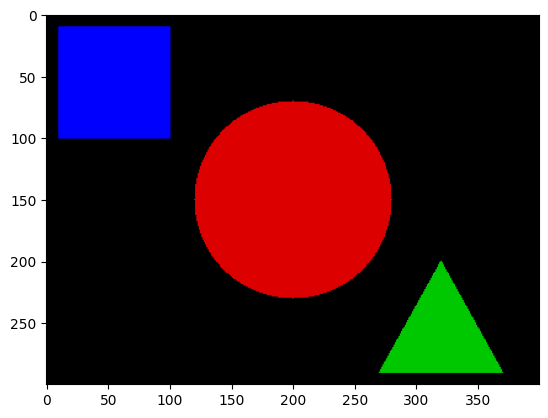

In [26]:
# HSV 마스킹으로 특정 색상 탐지 — 실습용 빨간색 이미지 생성 후 탐지
# 빨간색 원이 있는 테스트 이미지 만들기
test_image = np.zeros((300, 400, 3), dtype=np.uint8)
cv2.circle(test_image, (200, 150), 80, (0, 0, 220), -1)   # BGR: 빨간색 원 (R=220)
cv2.rectangle(test_image, (10, 10), (100, 100), (255, 0, 0), -1)  # BGR: 파란색 사각형

triangle_pts = np.array([[320, 200], [270, 290], [370, 290]], dtype=np.int32)
cv2.fillPoly(test_image, [triangle_pts], (0, 200, 0))         # BGR: 초록색 삼각형 (G=200)

print(f"테스트 이미지 shape: {test_image.shape}")
plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))

In [ ]:
# https://pseudopencv.site/utilities/hsvcolormask/

# 1. BGR → HSV 변환
hsv_test = cv2.cvtColor(test_image, cv2.COLOR_BGR2HSV)

# 2. 빨간색 HSV 범위 설정 (두 범위 모두 필요!)
lower_red1 = np.array([0,   120,  70])   # Hue=0 근처 하한
upper_red1 = np.array([10,  255, 255])   # Hue=0 근처 상한

lower_red2 = np.array([170, 120,  70])   # Hue=180 근처 하한
upper_red2 = np.array([180, 255, 255])   # Hue=180 근처 상한

# 3. 마스크 생성 (탐지 범위 픽셀=흰색, 나머지=검정)
mask1 = cv2.inRange(hsv_test, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv_test, lower_red2, upper_red2)
mask  = cv2.bitwise_or(mask1, mask2)   # 두 마스크 합치기

# 4. 원본에서 마스크 부분만 추출
detected = cv2.bitwise_and(test_image, test_image, mask=mask)

print(f"마스크에서 흰색 픽셀 수(탐지된 빨간 픽셀): {np.sum(mask > 0)}")

마스크에서 흰색 픽셀 수(탐지된 빨간 픽셀): 20081


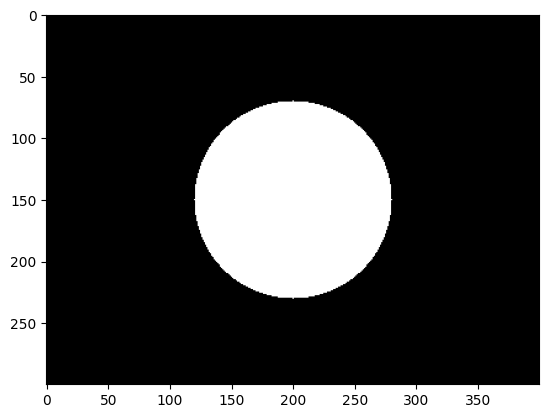

In [28]:
cv2.imwrite('mask_result.png', mask)
plt.imshow(mask, cmap="gray")
plt.show()

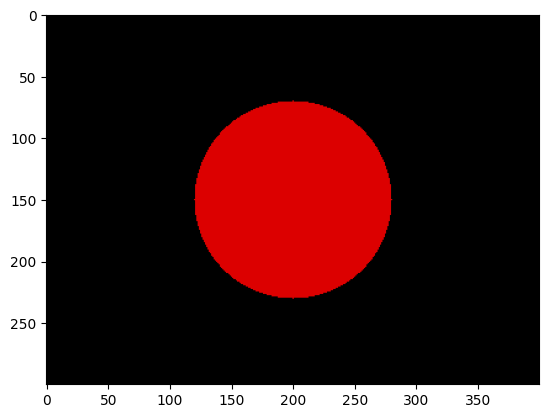

In [29]:
cv2.imwrite('detected_result.png', detected)
plt.imshow(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB))
plt.show()

In [30]:
# 1. 파란색 HSV 범위 설정
lower_blue = np.array([100, 120,  70])   # Hue=120 근처 하한
upper_blue = np.array([130, 255, 255])   # Hue=120 근처 상한

# 2. 마스크 생성 (탐지 범위 픽셀=흰색, 나머지=검정)
mask = cv2.inRange(hsv_test, lower_blue, upper_blue)

# 3. 원본에서 마스크 부분만 추출
detected = cv2.bitwise_and(test_image, test_image, mask=mask)

print(f"마스크에서 흰색 픽셀 수(탐지된 파란 픽셀): {np.sum(mask > 0)}")

마스크에서 흰색 픽셀 수(탐지된 파란 픽셀): 8281


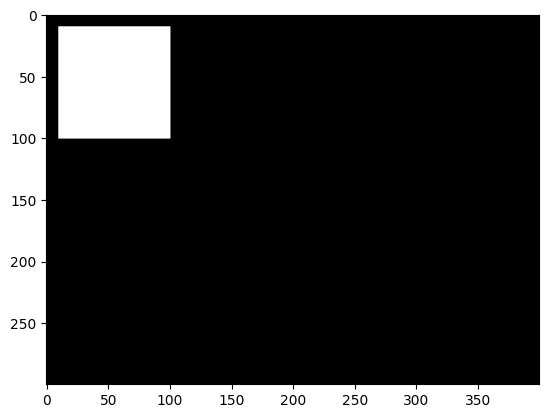

In [31]:
cv2.imwrite('mask_result.png', mask)
plt.imshow(mask, cmap="gray")
plt.show()

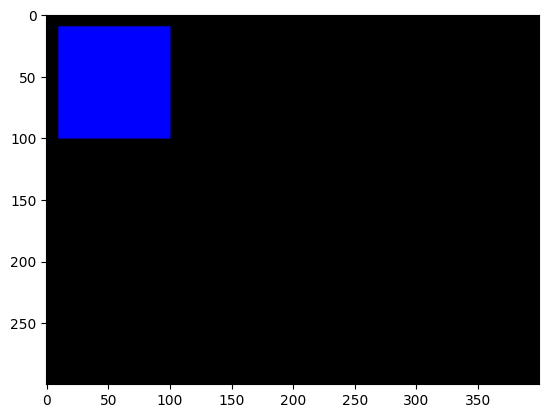

In [32]:
cv2.imwrite('detected_result.png', detected)
plt.imshow(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB))
plt.show()

In [33]:
# 1. 초록색 HSV 범위 설정
lower_green = np.array([40, 120,  70])   # Hue=60 근처 하한
upper_green = np.array([80, 255, 255])   # Hue=60 근처 상한

# 2. 마스크 생성 (탐지 범위 픽셀=흰색, 나머지=검정)
mask = cv2.inRange(hsv_test, lower_green, upper_green)

# 3. 원본에서 마스크 부분만 추출
detected = cv2.bitwise_and(test_image, test_image, mask=mask)

print(f"마스크에서 흰색 픽셀 수(탐지된 초록 픽셀): {np.sum(mask > 0)}")

마스크에서 흰색 픽셀 수(탐지된 초록 픽셀): 4641


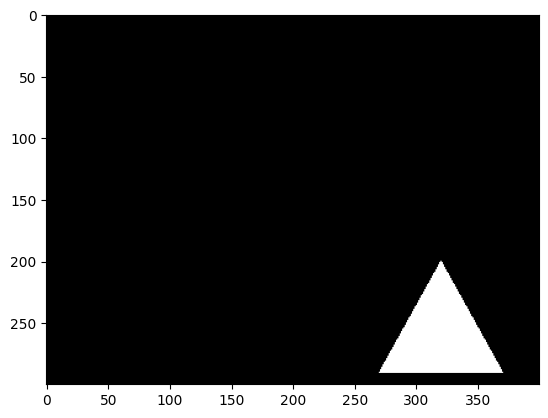

In [34]:
cv2.imwrite('mask_result.png', mask)
plt.imshow(mask, cmap="gray")
plt.show()

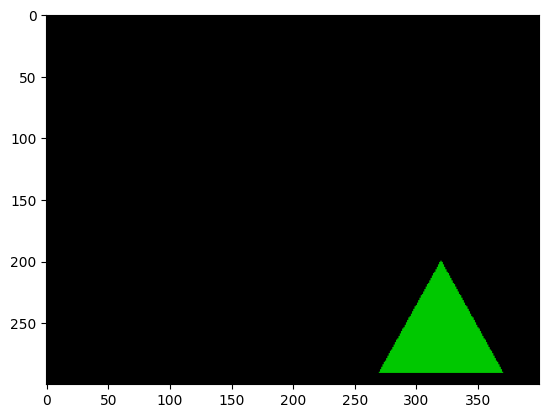

In [36]:
cv2.imwrite('detected_result.png', detected)
plt.imshow(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB))
plt.show()

---
## Part 5: 퀴즈 & 복습

강의에서 배운 핵심 개념을 코드로 확인하는 복습 문제입니다.

### 5.1 TODO 실습 — 빈칸 채우기 실습

In [5]:
# TODO: 여기에 구현하세요
# 빈칸 채우기 문제 1
# 이미지 파일을 불러와 NumPy 배열로 로드하는 OpenCV 함수를 사용하여
# 'sample.jpg' 파일을 읽고 shape를 출력하세요.
# 힌트: cv2.imread()
import cv2

def load_and_print_shape(filepath):
    img = cv2.imread(filepath)
    if img is None:
        print(f"[ERROR] 이미지를 읽을 수 없습니다: '{filepath}'")
        print("       → 파일 경로가 올바른지, 확장자가 맞는지 확인하세요.")
        return
    print(f"이미지 shape: {img.shape}")

load_and_print_shape('sample.jpg')

이미지 shape: (5464, 8192, 3)


In [23]:
# TODO: 여기에 구현하세요
# 빈칸 채우기 문제 2
# 주어진 BGR 이미지를 HSV로 변환하고
# 특정 파란색 범위(lower_blue, upper_blue)로 마스크를 생성하세요.
# 파란색 HSV 범위: Hue=100~130, Saturation=100~255, Value=50~255

from matplotlib.pylab import rint

import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_blue_object(_bgr_image):
    """파란색 물체를 탐지하여 마스크를 반환합니다."""
    # TODO: 여기에 구현하세요
    # 1. BGR → HSV 변환
    # 2. 파란색 범위 설정
    # 3. inRange로 마스크 생성
    # 4. 마스크 반환
    hsv_test = cv2.cvtColor(_bgr_image, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([100, 120,  70])   # Hue=120 근처 하한
    upper_blue = np.array([130, 255, 255])   # Hue=120 근처 상한

# 2. 마스크 생성 (탐지 범위 픽셀=흰색, 나머지=검정)
    mask = cv2.inRange(hsv_test, lower_blue, upper_blue)
    return mask 

# 완성 후 주석 해제
image = cv2.imread("sample.jpg")
blue_mask = detect_blue_object(image)
print(f"파란색 탐지 픽셀 수: {np.sum(blue_mask > 0)}")

파란색 탐지 픽셀 수: 3730


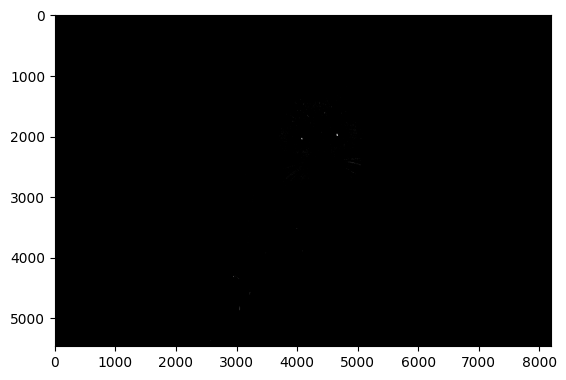

In [24]:
plt.imshow(blue_mask, cmap="gray")
plt.show()

In [18]:
# TODO: 여기에 구현하세요
# 종합 실습: 이미지 읽기 → 색공간 변환 → 저장 파이프라인
# 아래 함수를 완성하여 전체 처리 흐름을 구현하세요.
# 요구사항:
#   1. input_path에서 이미지 읽기
#   2. BGR → Grayscale 변환
#   3. BGR → HSV 변환
#   4. Grayscale 이미지를 output_gray_path에 저장
#   5. 각 단계별 shape 출력
import cv2
import numpy as np

def image_processing_pipeline(_input_path, _output_gray_path):
    """이미지 처리 파이프라인: 읽기 → 변환 → 저장"""
    # TODO: 여기에 구현하세요
    image = cv2.imread(_input_path)
    if image is None:
        print(f"[ERROR] 이미지를 읽을 수 없습니다: '{_input_path}'")
        print("       → 파일 경로가 올바른지, 확장자가 맞는지 확인하세요.")
        return
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print(gray_img.shape)

    hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    print(hsv_img.shape)

    cv2.imwrite(_output_gray_path, gray_img)


# 완성 후 주석 해제
image_processing_pipeline('sample.jpg', 'output_gray.png')

(5464, 8192)
(5464, 8192, 3)
